# Notebook 04 – Análisis Exploratorio

**Objetivo:** entender la estructura de los datos antes de cualquier análisis supervisado.

Se realizará:
- **PCA sobre experimentos**: cómo se relacionan los 17 experimentos entre sí en el espacio de los 279 picos cromatográficos.
- **Análisis de correlaciones**: qué tan similares son los experimentos entre sí en términos de intensidades log₂.
- **Compuestos más variables**: identificar qué picos presentan mayor variabilidad entre experimentos.

> **Nota:** El experimento Exp_9 fue marcado como outlier en el notebook 03 y se destacará en rojo en todas las visualizaciones.

In [5]:
# ── Importaciones ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PROC = Path('../data/processed')
FIGS = Path('../results/figures')
print('✓ Librerías importadas')

✓ Librerías importadas


## 1. Carga de datos

In [6]:
# ── Carga de matrices preprocesadas ────────────────────────────────────────────
X_prep = pd.read_csv(DATA_PROC / 'X_preprocessed.csv')
X_log2_df = pd.read_csv(DATA_PROC / 'X_log2.csv')

# Ordenar columnas de experimentos NUMÉRICAMENTE (Exp_1, Exp_2, ..., Exp_17)
# sin este sort quedarían en orden alfabético: Exp_1, Exp_10, Exp_11 ...
exp_cols = sorted([c for c in X_prep.columns if c.startswith('Exp_')],
                  key=lambda x: int(x.split('_')[1].split('.')[0]))
exp_labels = [c.replace('.CDF', '') for c in exp_cols]
meta_cols = ['compound_name', 'hit_match_factor', 'match_quality', 'retention_time']

# Matriz principal: picos × experimentos (279 × 17)
X = X_prep[exp_cols].values
X_log2 = X_log2_df[exp_cols].values

# Para PCA sobre experimentos: transponer → experimentos × picos (17 × 279)
X_exp = X.T  # 17 × 279

print('=' * 60)
print('DATOS CARGADOS')
print('=' * 60)
print(f'Picos (filas):        {X.shape[0]}')
print(f'Experimentos (cols):  {X.shape[1]}')
print(f'Compuestos únicos:    {X_prep["compound_name"].nunique()}')

DATOS CARGADOS
Picos (filas):        279
Experimentos (cols):  17
Compuestos únicos:    143


## 2. PCA sobre experimentos

Se analiza cómo se relacionan los 17 experimentos entre sí en el espacio de los 279 picos cromatográficos. Cada punto en el PCA representa un experimento. Esto permite detectar grupos de experimentos similares, outliers y la estructura global del dataset.

In [7]:
# ── PCA sobre experimentos (17 × 279) ──────────────────────────────────────────
pca_exp = PCA()
X_pca_exp = pca_exp.fit_transform(X_exp)  # resultado: 17 × 17
var_ratio = pca_exp.explained_variance_ratio_
cumvar = np.cumsum(var_ratio)

print('Varianza explicada por componente:')
for i, (v, c) in enumerate(zip(var_ratio[:6], cumvar[:6])):
    print(f'  PC{i+1}: {v*100:.1f}%  (acumulada: {c*100:.1f}%)')

Varianza explicada por componente:
  PC1: 70.3%  (acumulada: 70.3%)
  PC2: 8.6%  (acumulada: 78.9%)
  PC3: 6.4%  (acumulada: 85.3%)
  PC4: 4.4%  (acumulada: 89.8%)
  PC5: 3.1%  (acumulada: 92.9%)
  PC6: 1.7%  (acumulada: 94.6%)


## 3. Visualizaciones PCA

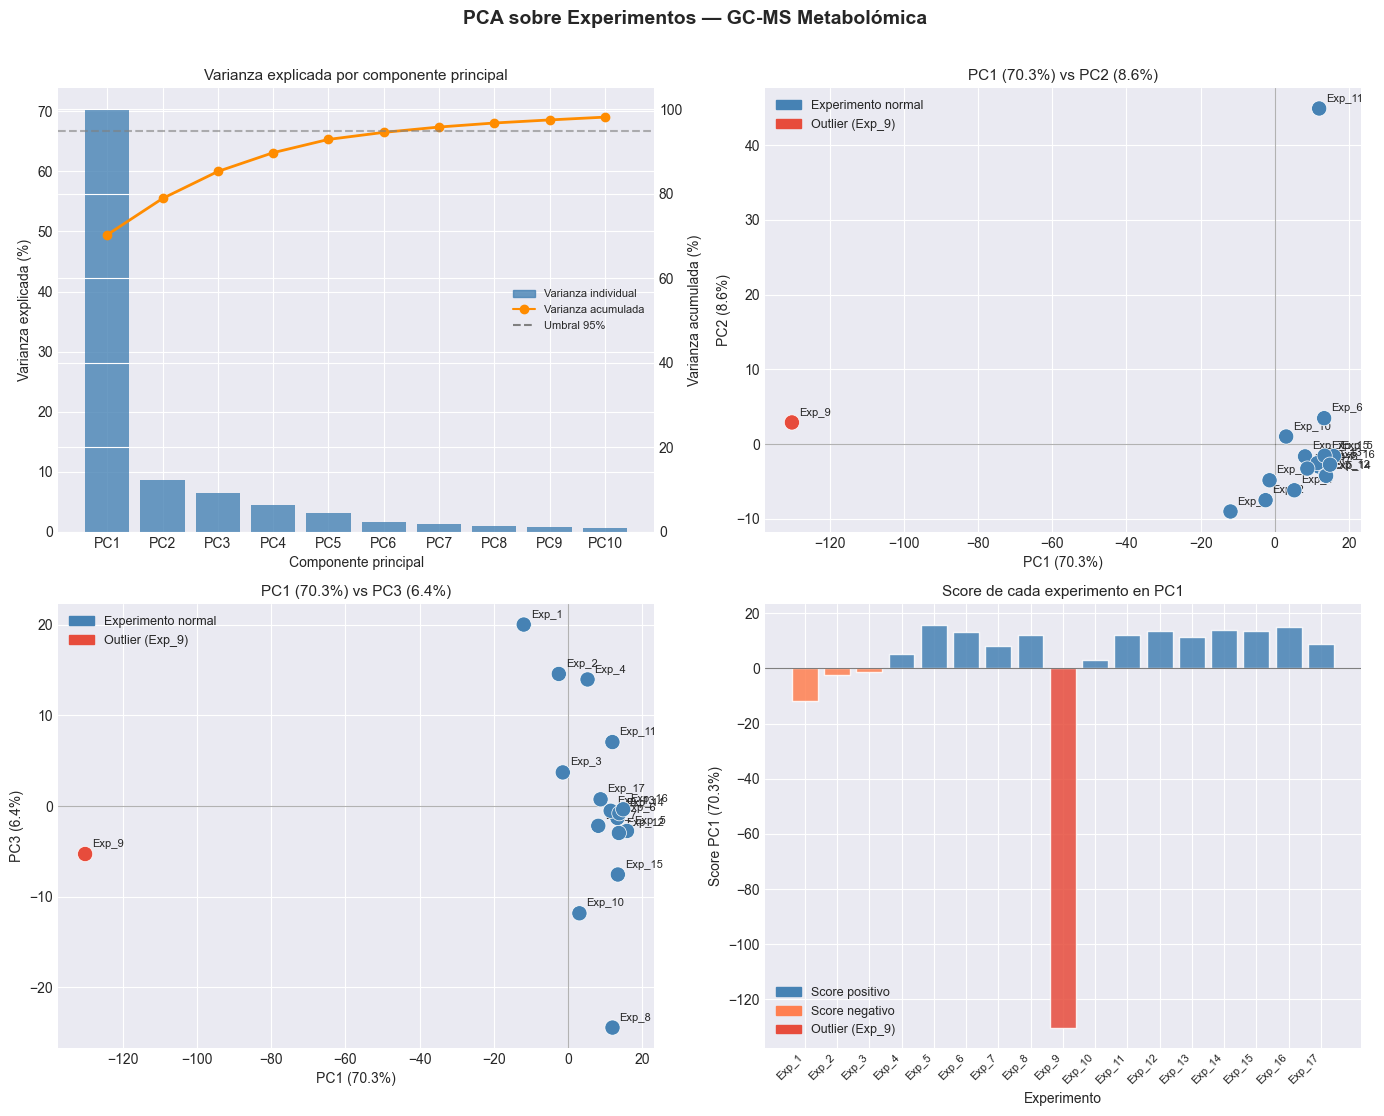

✓ Figura guardada: results/figures/04_pca_experiments.png


In [8]:
# ── Panel 2×2 con visualizaciones PCA ──────────────────────────────────────────
outlier_idx = exp_labels.index('Exp_9')
colors_exp  = ['#e74c3c' if i == outlier_idx else 'steelblue' for i in range(len(exp_labels))]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('PCA sobre Experimentos — GC-MS Metabolómica', fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Scree plot ─────────────────────────────────────────────────────────
ax = axes[0, 0]
n_pcs = min(10, len(var_ratio))
pc_labels_x = [f'PC{i+1}' for i in range(n_pcs)]

ax.bar(pc_labels_x, var_ratio[:n_pcs] * 100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(pc_labels_x, cumvar[:n_pcs] * 100, 'o-', color='darkorange', linewidth=2, markersize=6)
ax2.axhline(95, color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Varianza acumulada (%)', fontsize=10)
ax2.set_ylim(0, 105)
ax.set_title('Varianza explicada por componente principal', fontsize=11)
ax.set_xlabel('Componente principal', fontsize=10)
ax.set_ylabel('Varianza explicada (%)', fontsize=10)

bars_p  = mpatches.Patch(color='steelblue', alpha=0.8, label='Varianza individual')
line_p  = plt.Line2D([0], [0], color='darkorange', marker='o', label='Varianza acumulada')
thr_p   = plt.Line2D([0], [0], color='gray', linestyle='--', label='Umbral 95%')
ax.legend(handles=[bars_p, line_p, thr_p], fontsize=8, loc='center right')

# ── Plot 2: PC1 vs PC2 ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.scatter(X_pca_exp[:, 0], X_pca_exp[:, 1], c=colors_exp, s=120, zorder=5,
           edgecolors='white', linewidths=0.5)
for i, label in enumerate(exp_labels):
    ax.annotate(label, (X_pca_exp[i, 0], X_pca_exp[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
ax.axvline(0, color='black', alpha=0.3, linewidth=0.8)
ax.set_title(f'PC1 ({var_ratio[0]*100:.1f}%) vs PC2 ({var_ratio[1]*100:.1f}%)', fontsize=11)
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}%)', fontsize=10)
legend_n = mpatches.Patch(color='steelblue', label='Experimento normal')
legend_o = mpatches.Patch(color='#e74c3c', label='Outlier (Exp_9)')
ax.legend(handles=[legend_n, legend_o], fontsize=9)

# ── Plot 3: PC1 vs PC3 ─────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(X_pca_exp[:, 0], X_pca_exp[:, 2], c=colors_exp, s=120, zorder=5,
           edgecolors='white', linewidths=0.5)
for i, label in enumerate(exp_labels):
    ax.annotate(label, (X_pca_exp[i, 0], X_pca_exp[i, 2]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
ax.axvline(0, color='black', alpha=0.3, linewidth=0.8)
ax.set_title(f'PC1 ({var_ratio[0]*100:.1f}%) vs PC3 ({var_ratio[2]*100:.1f}%)', fontsize=11)
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC3 ({var_ratio[2]*100:.1f}%)', fontsize=10)
ax.legend(handles=[legend_n, legend_o], fontsize=9)

# ── Plot 4: Score PC1 por experimento ─────────────────────────────────────────
# X_pca_exp[:,0] = score de cada experimento en PC1 (shape 17)
ax = axes[1, 1]
scores_pc1 = X_pca_exp[:, 0]
bar_colors = ['#e74c3c' if i == outlier_idx else ('steelblue' if v >= 0 else 'coral')
              for i, v in enumerate(scores_pc1)]
ax.bar(exp_labels, scores_pc1, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Score de cada experimento en PC1', fontsize=11)
ax.set_xlabel('Experimento', fontsize=10)
ax.set_ylabel(f'Score PC1 ({var_ratio[0]*100:.1f}%)', fontsize=10)
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=8)

pos_p = mpatches.Patch(color='steelblue', label='Score positivo')
neg_p = mpatches.Patch(color='coral',     label='Score negativo')
out_p = mpatches.Patch(color='#e74c3c',   label='Outlier (Exp_9)')
ax.legend(handles=[pos_p, neg_p, out_p], fontsize=9)

plt.tight_layout()
FIGS.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGS / '04_pca_experiments.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura guardada: results/figures/04_pca_experiments.png')

## Zoom de los PCA para aclarar los resultados

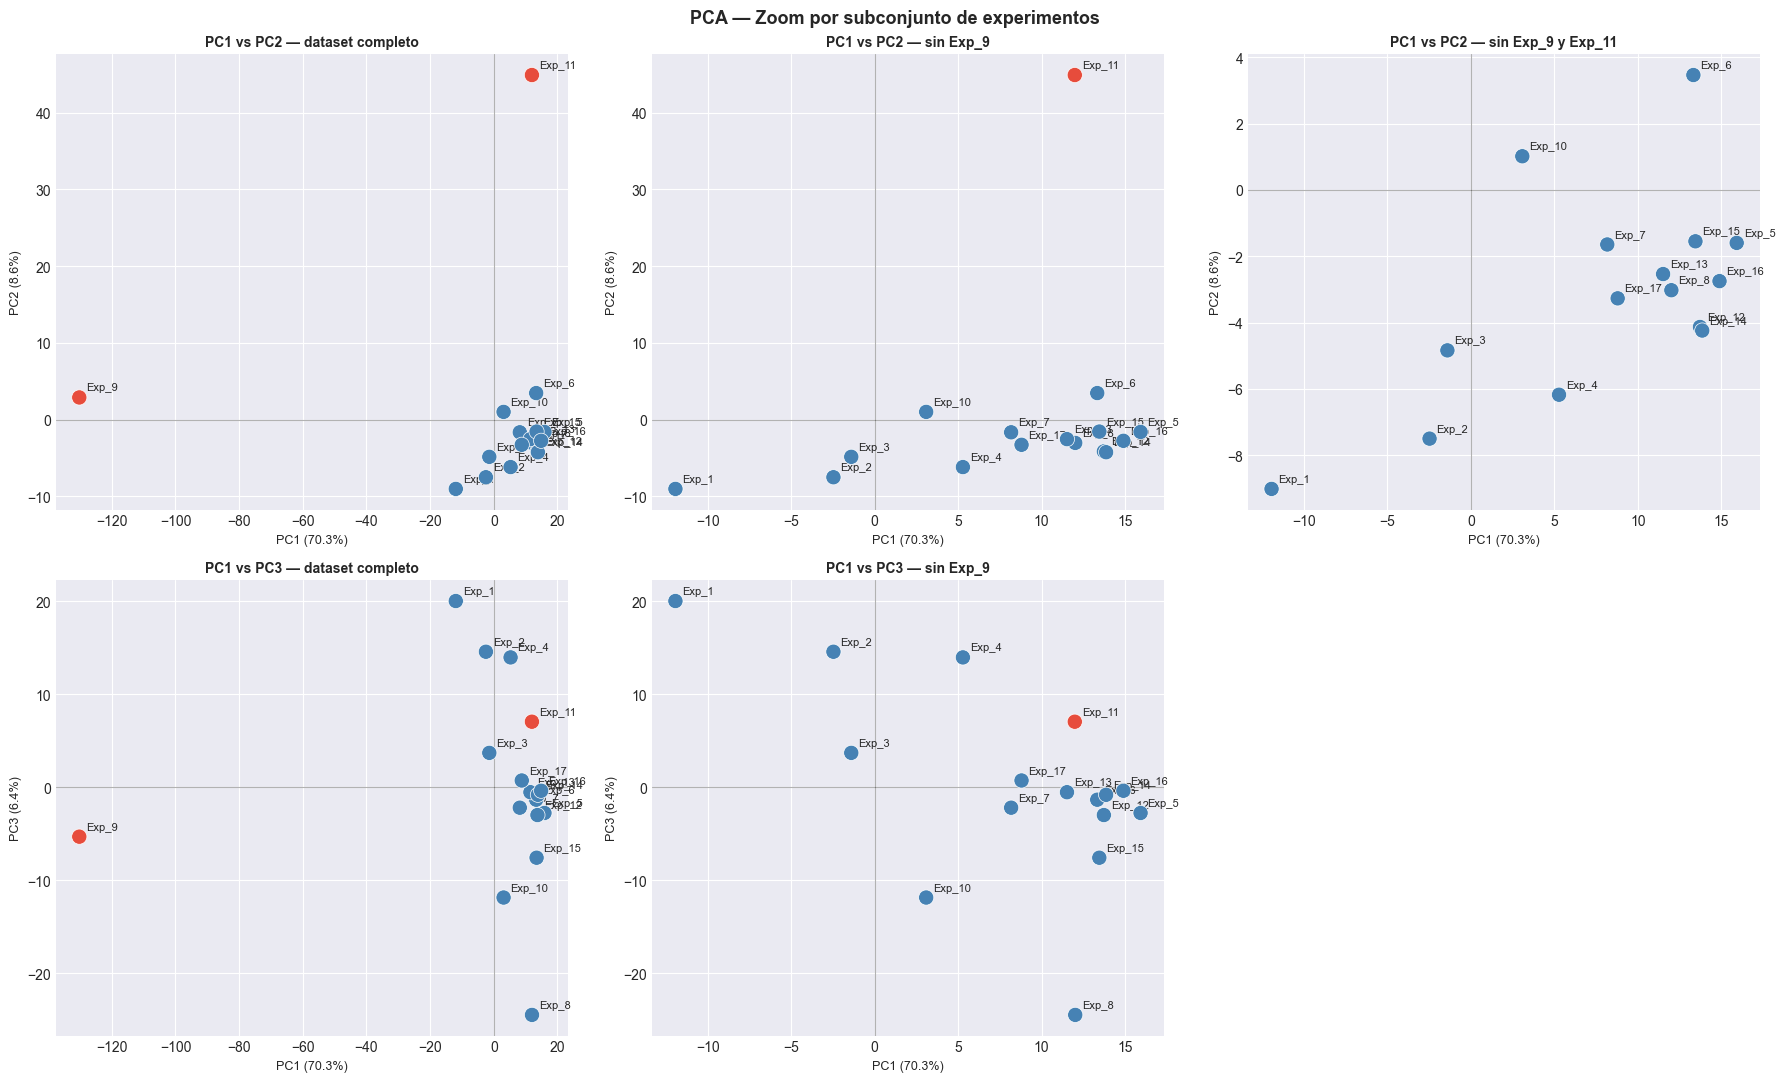

✓ Figura guardada: results/figures/04_pca_zoom.png


In [13]:
# ── Zoom plots: subconjuntos de experimentos ───────────────────────────────────
# Usar los scores ya calculados (X_pca_exp), solo filtrar filas
scores_df = pd.DataFrame(X_pca_exp, index=exp_labels,
                         columns=[f'PC{i+1}' for i in range(X_pca_exp.shape[1])])

EXCLUDE_9     = ['Exp_9']
EXCLUDE_9_11  = ['Exp_9', 'Exp_11']
OUTLIER_COLOR = '#e74c3c'

def scatter_zoom(ax, df, pc_x, pc_y, exclude, title, var_ratio):
    """Scatter de experimentos filtrando los excluidos."""
    subset = df[~df.index.isin(exclude)]
    colors = [OUTLIER_COLOR if exp in EXCLUDE_9_11 else 'steelblue'
              for exp in subset.index]
    ax.scatter(subset[pc_x], subset[pc_y], c=colors, s=120,
               zorder=5, edgecolors='white', linewidths=0.5)
    for exp in subset.index:
        ax.annotate(exp, (subset.loc[exp, pc_x], subset.loc[exp, pc_y]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)
    ax.axvline(0, color='black', alpha=0.3, linewidth=0.8)
    pcx_n = int(pc_x[2]) - 1
    pcy_n = int(pc_y[2]) - 1
    ax.set_xlabel(f'{pc_x} ({var_ratio[pcx_n]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'{pc_y} ({var_ratio[pcy_n]*100:.1f}%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('PCA — Zoom por subconjunto de experimentos', fontsize=13, fontweight='bold')

# Fila 1: PC1 vs PC2
scatter_zoom(axes[0, 0], scores_df, 'PC1', 'PC2', [],
             'PC1 vs PC2 — dataset completo', var_ratio)
scatter_zoom(axes[0, 1], scores_df, 'PC1', 'PC2', EXCLUDE_9,
             'PC1 vs PC2 — sin Exp_9', var_ratio)
scatter_zoom(axes[0, 2], scores_df, 'PC1', 'PC2', EXCLUDE_9_11,
             'PC1 vs PC2 — sin Exp_9 y Exp_11', var_ratio)

# Fila 2: PC1 vs PC3 (solo completo y sin Exp_9; 3er eje vacío)
scatter_zoom(axes[1, 0], scores_df, 'PC1', 'PC3', [],
             'PC1 vs PC3 — dataset completo', var_ratio)
scatter_zoom(axes[1, 1], scores_df, 'PC1', 'PC3', EXCLUDE_9,
             'PC1 vs PC3 — sin Exp_9', var_ratio)
axes[1, 2].axis('off')  # celda vacía

plt.tight_layout()
plt.savefig(FIGS / '04_pca_zoom.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/04_pca_zoom.png')

## 4. Correlación entre experimentos

La matriz de correlación muestra qué tan similares son los perfiles de intensidad de cada par de experimentos. Se usan las intensidades log₂ (más interpretables que los valores escalados) para calcular las correlaciones de Pearson.

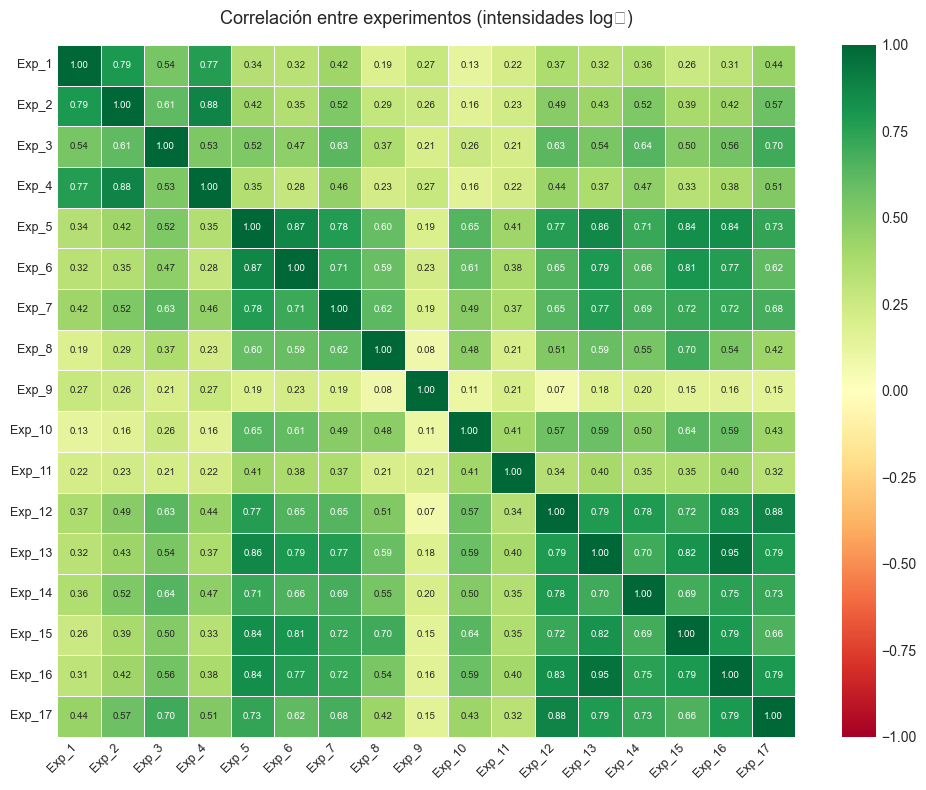

✓ Figura guardada en ..\results\figures\04_correlation_experiments.png

Correlación mínima entre experimentos: 0.0719
Correlación máxima entre experimentos: 0.9488


In [9]:
# ── Matriz de correlación entre experimentos ────────────────────────────────────
# X_log2 tiene shape (279 picos × 17 experimentos)
# .corr() calcula correlación entre las 17 columnas (experimentos) a través de los 279 picos
corr_df = pd.DataFrame(X_log2, columns=exp_labels).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df,
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 7})

ax.set_title('Correlación entre experimentos (intensidades log₂)', fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / '04_correlation_experiments.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura guardada en {FIGS / "04_correlation_experiments.png"}')

# Estadísticas de correlación (excluyendo la diagonal)
corr_vals = corr_df.values.copy()
np.fill_diagonal(corr_vals, np.nan)
_min_corr = np.nanmin(corr_vals)
_max_corr = np.nanmax(corr_vals)

print(f'\nCorrelación mínima entre experimentos: {_min_corr:.4f}')
print(f'Correlación máxima entre experimentos: {_max_corr:.4f}')

## 5. Compuestos más variables

Se identifican los picos cromatográficos con mayor varianza entre los 17 experimentos. Estos compuestos son candidatos a biomarcadores o representan las diferencias más importantes entre condiciones experimentales.

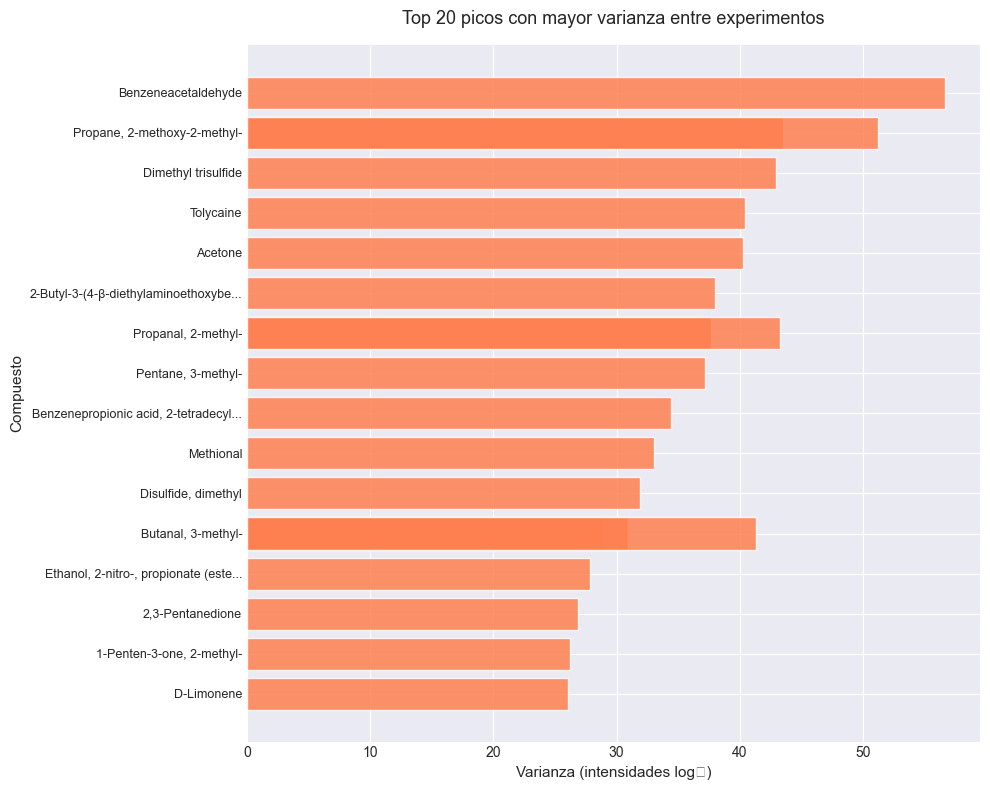

✓ Figura guardada en ..\results\figures\04_top_variable_compounds.png

Top 20 picos con mayor varianza:
                                          compound_name  hit_match_factor   variance
0                                   Benzeneacetaldehyde               855  56.677565
1                          Propane, 2-methoxy-2-methyl-               952  51.193666
2                          Propane, 2-methoxy-2-methyl-               909  43.555302
3                                   Propanal, 2-methyl-               926  43.273965
4                                   Dimethyl trisulfide               921  42.944900
5                                    Butanal, 3-methyl-               898  41.352241
6                                             Tolycaine               873  40.428576
7                                               Acetone               771  40.304543
8   2-Butyl-3-(4-β-diethylaminoethoxybenzoyl)benzofuran               842  38.026194
9                                   Propanal, 

In [10]:
# ── Top 20 picos con mayor varianza ────────────────────────────────────────────
# Calcular varianza de cada pico a través de los 17 experimentos usando X_log2
variances = np.var(X_log2, axis=1)  # varianza por fila (por pico)

# Construir DataFrame con metadata + varianza
var_df = X_prep[meta_cols].copy()
var_df['variance'] = variances
top20 = var_df.nlargest(20, 'variance').reset_index(drop=True)

# Truncar nombres largos para el gráfico
top20['compound_short'] = top20['compound_name'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x
)

# ── Gráfico horizontal de barras ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

# Ordenar descendente para el gráfico (el mayor arriba)
top20_sorted = top20.sort_values('variance', ascending=True)
ax.barh(top20_sorted['compound_short'], top20_sorted['variance'],
        color='coral', alpha=0.85, edgecolor='white')

ax.set_title('Top 20 picos con mayor varianza entre experimentos', fontsize=13, pad=15)
ax.set_xlabel('Varianza (intensidades log₂)', fontsize=11)
ax.set_ylabel('Compuesto', fontsize=11)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(FIGS / '04_top_variable_compounds.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Figura guardada en {FIGS / "04_top_variable_compounds.png"}')

# ── Tabla de los top 20 ───────────────────────────────────────────────────────
print('\nTop 20 picos con mayor varianza:')
print('=' * 70)
display_cols = ['compound_name', 'hit_match_factor', 'variance']
print(top20[display_cols].to_string(index=True))

## Análisis de datos

El análisis de componentes principales muestra que la PC1 explica el 70.3% de la varianza total, mientras que PC2 y PC3 explican el 8.6% y 6.4% respectivamente. Esto indica que gran parte de la variabilidad entre experimentos está concentrada en una única dirección principal.

En los gráficos PC1 vs PC2 y PC1 vs PC3, el experimento Exp_9 aparece claramente separado del resto, lo que sugiere que se trata de una observación atípica dentro del conjunto de datos. Esta diferencia también se observa en la matriz de correlación, donde Exp_9 presenta valores de correlación significativamente más bajos con respecto al resto de experimentos.

Al representar los PCA en formato zoom, excluyendo Exp_9 (y en un caso también Exp_11), se aprecia mejor la distribución del resto de muestras. En este subconjunto, la mayoría de experimentos se agrupan en una región relativamente compacta, lo que sugiere una cierta homogeneidad en los perfiles metabolómicos. No obstante, algunos experimentos como Exp_1, Exp_8, Exp_10 o Exp_11 muestran posiciones algo más diferenciadas, lo que indica variabilidad adicional dentro del grupo principal.

La matriz de correlación confirma esta estructura. La mayoría de experimentos presentan correlaciones moderadas o altas, mientras que Exp_9 vuelve a mostrar valores claramente más bajos, reforzando su carácter atípico.

Finalmente, el análisis de los 20 picos con mayor varianza permite identificar los compuestos que más contribuyen a las diferencias observadas entre experimentos. Estos compuestos son los que probablemente influyen en la separación observada en el PCA, aunque una alta varianza no implica necesariamente relevancia biológica directa, por lo que sería necesario revisarlos individualmente en análisis posteriores.

En conjunto, los resultados indican que el dataset presenta una estructura global relativamente consistente, con un experimento claramente discordante (Exp_9) y una variabilidad moderada entre el resto de muestras.

## Conclusiones

En general, los experimentos Exp_12, Exp_13, Exp_15, Exp_16 y Exp_17 muestran los perfiles más consistentes, ya que presentan altas correlaciones entre sí y una posición relativamente compacta en el espacio PCA. Esto sugiere que constituyen el grupo más representativo y estable del conjunto de datos, en contraste con experimentos más atípicos como Exp_9.

## 6. Guardar resultados PCA

In [11]:
# ── Guardar coordenadas PCA de los 17 experimentos ─────────────────────────────
pca_results = pd.DataFrame({
    'experiment': exp_labels,
    'PC1': X_pca_exp[:, 0],
    'PC2': X_pca_exp[:, 1],
    'PC3': X_pca_exp[:, 2],
    'is_outlier': [label == 'Exp_9' for label in exp_labels]
})

output_path = DATA_PROC / 'pca_experiments.csv'
pca_results.to_csv(output_path, index=False)

print(f'✓ Resultados PCA guardados en: {output_path}')
print()
print(pca_results.to_string(index=False))

✓ Resultados PCA guardados en: ..\data\processed\pca_experiments.csv

experiment         PC1       PC2        PC3  is_outlier
     Exp_1  -11.931741 -9.013861  20.028389       False
     Exp_2   -2.470289 -7.498291  14.577960       False
     Exp_3   -1.401738 -4.837267   3.708598       False
     Exp_4    5.282419 -6.174555  13.968888       False
     Exp_5   15.921551 -1.596609  -2.752705       False
     Exp_6   13.327525  3.465088  -1.325962       False
     Exp_7    8.172148 -1.644392  -2.184459       False
     Exp_8   12.009606 -3.023679 -24.455512       False
     Exp_9 -130.207605  2.895495  -5.298821        True
    Exp_10    3.084144  1.015557 -11.841436       False
    Exp_11   11.981460 44.885327   7.057269       False
    Exp_12   13.722512 -4.130688  -2.975983       False
    Exp_13   11.514660 -2.536057  -0.522278       False
    Exp_14   13.858156 -4.239035  -0.798332       False
    Exp_15   13.451039 -1.548800  -7.560890       False
    Exp_16   14.892481 -2.749670  

## Análisis de los datos



## Resumen

Síntesis de los principales hallazgos del análisis exploratorio.

In [12]:
# ── Resumen de resultados ──────────────────────────────────────────────────────
# Número de componentes necesarios para explicar el 95% de la varianza
n_95 = np.searchsorted(cumvar, 0.95) + 1

# Posición de Exp_9 en el PCA
exp9_pc1 = X_pca_exp[outlier_idx, 0]
exp9_pc2 = X_pca_exp[outlier_idx, 1]

# Top 3 compuestos más variables
top3 = top20['compound_name'].head(3).tolist()

print('=' * 65)
print('RESUMEN — ANÁLISIS EXPLORATORIO (Notebook 04)')
print('=' * 65)
print(f'Matriz analizada:          279 picos × 17 experimentos')
print(f'PC1 varianza:              {var_ratio[0]*100:.1f}%')
print(f'PC2 varianza:              {var_ratio[1]*100:.1f}%')
print(f'PC3 varianza:              {var_ratio[2]*100:.1f}%')
print(f'Componentes para 95%:      {n_95}')
print(f'Posición Exp_9 (PC1, PC2): ({exp9_pc1:.3f}, {exp9_pc2:.3f})')
print(f'Correlación mínima:        {_min_corr:.4f}')
print(f'Correlación máxima:        {_max_corr:.4f}')
print()
print('Top 3 compuestos más variables:')
for i, name in enumerate(top3, 1):
    print(f'  {i}. {name}')
print('=' * 65)

RESUMEN — ANÁLISIS EXPLORATORIO (Notebook 04)
Matriz analizada:          279 picos × 17 experimentos
PC1 varianza:              70.3%
PC2 varianza:              8.6%
PC3 varianza:              6.4%
Componentes para 95%:      7
Posición Exp_9 (PC1, PC2): (-130.208, 2.895)
Correlación mínima:        0.0719
Correlación máxima:        0.9488

Top 3 compuestos más variables:
  1. Benzeneacetaldehyde
  2. Propane, 2-methoxy-2-methyl-
  3. Propane, 2-methoxy-2-methyl-
